# Student Performance Prediction Using Machine Learning
### AI & ML Internship Project — End-to-End Notebook

This notebook walks through the complete machine learning pipeline:
data loading, cleaning, exploratory data analysis (EDA), feature
engineering, model training & comparison, evaluation, and prediction
on new student records.

**Author:** Balamurugan S — B.Tech Information Technology
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Joblib


## 1. Imports & Setup

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import preprocessing as pp
from feature_engineering import add_derived_features, drop_unnecessary_columns, correlation_analysis, get_feature_importance
from visualization import (
    plot_correlation_heatmap, plot_histograms, plot_boxplots,
    plot_countplots, plot_pairplot, plot_result_vs_feature
)
from train_model import build_dataset, train_and_compare, save_artifacts
from evaluation import compute_metrics, plot_confusion_matrix, print_classification_report, plot_roc_curves

sns.set_theme(style='whitegrid')
%matplotlib inline


## 2. Load the Dataset

The dataset (`student_performance.csv`) contains 600+ synthetic but
realistically-distributed student records with academic and lifestyle
features, and a target column `Final_Result` (Pass / Average / Fail).

In [2]:
DATA_PATH = '../dataset/student_performance.csv'
df = pp.load_data(DATA_PATH)
df.head()


[preprocessing] Loaded 605 rows, 13 columns from ../dataset/student_performance.csv


,Student_ID,Gender,Age,Attendance,Study_Hours_Per_Day,Previous_Marks,Assignment_Score,Internal_Marks,Sleep_Hours,Internet_Usage,Participation,Family_Support,Final_Result
0,STU0001,Male,16,81.9,4.5,61.1,66.1,34.3,5.8,1.1,Medium,Low,Pass
1,STU0002,Female,17,63.0,2.8,89.0,66.1,31.5,6.9,3.2,Medium,High,Average
2,STU0003,Female,19,89.1,3.6,73.4,81.1,27.2,7.6,1.2,High,Medium,Pass
3,STU0004,Female,17,75.8,3.7,60.6,74.8,31.5,6.2,1.6,High,Low,Average
4,STU0005,Male,16,71.7,2.3,75.5,78.0,23.8,7.8,2.2,Low,Medium,Fail


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           605 non-null    str    
 1   Gender               605 non-null    str    
 2   Age                  605 non-null    int64  
 3   Attendance           596 non-null    float64
 4   Study_Hours_Per_Day  605 non-null    float64
 5   Previous_Marks       605 non-null    float64
 6   Assignment_Score     596 non-null    float64
 7   Internal_Marks       605 non-null    float64
 8   Sleep_Hours          596 non-null    float64
 9   Internet_Usage       605 non-null    float64
 10  Participation        605 non-null    str    
 11  Family_Support       605 non-null    str    
 12  Final_Result         605 non-null    str    
dtypes: float64(7), int64(1), str(5)
memory usage: 61.6 KB


In [4]:
df.describe(include='all')


,Student_ID,Gender,Age,Attendance,Study_Hours_Per_Day,Previous_Marks,Assignment_Score,Internal_Marks,Sleep_Hours,Internet_Usage,Participation,Family_Support,Final_Result
count,605,605,605.000000,596.000000,605.000000,605.000000,596.000000,605.000000,596.000000,605.000000,605,605,605
unique,600,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3
top,STU0202,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,Medium,Average
freq,2,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,277,284,243
mean,NaN,NaN,17.467769,78.959899,3.297521,65.099504,69.809564,28.155702,6.389430,2.952397,NaN,NaN,NaN
std,NaN,NaN,1.092283,11.558882,1.448216,14.479525,13.793886,6.094998,1.211127,1.650762,NaN,NaN,NaN
min,NaN,NaN,16.000000,43.200000,0.000000,20.000000,28.100000,10.400000,3.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,17.000000,71.075000,2.300000,55.300000,61.100000,23.600000,5.600000,1.800000,NaN,NaN,NaN
50%,NaN,NaN,17.000000,79.500000,3.200000,65.100000,69.600000,28.300000,6.400000,3.000000,NaN,NaN,NaN
75%,NaN,NaN,18.000000,86.500000,4.200000,75.100000,78.700000,32.400000,7.100000,4.200000,NaN,NaN,NaN


## 3. Data Preprocessing

Steps performed:
1. Handle missing values (median for numeric, mode for categorical)
2. Remove duplicate rows
3. Detect & cap outliers using the IQR method
4. Encode categorical variables
5. Scale numeric features
6. Train-test split (stratified)

In [5]:
print('Missing values before cleaning:')
print(df.isna().sum())


Missing values before cleaning:
Student_ID             0
Gender                 0
Age                    0
Attendance             9
Study_Hours_Per_Day    0
Previous_Marks         0
Assignment_Score       9
Internal_Marks         0
Sleep_Hours            9
Internet_Usage         0
Participation          0
Family_Support         0
Final_Result           0
dtype: int64


In [6]:
df_clean = pp.handle_missing_values(df)
df_clean = pp.remove_duplicates(df_clean)
df_clean = pp.handle_outliers(df_clean)
print('Missing values after cleaning:', df_clean.isna().sum().sum())
print('Shape after cleaning:', df_clean.shape)


[preprocessing] Missing values handled (numeric -> median, categorical -> mode)
[preprocessing] Removed 5 duplicate rows
[preprocessing] Capped 2 outliers in 'Attendance'
[preprocessing] Capped 3 outliers in 'Study_Hours_Per_Day'
[preprocessing] Capped 2 outliers in 'Previous_Marks'
[preprocessing] Capped 6 outliers in 'Assignment_Score'
[preprocessing] Capped 1 outliers in 'Internal_Marks'
[preprocessing] Capped 8 outliers in 'Sleep_Hours'
[preprocessing] Capped 2 outliers in 'Internet_Usage'
Missing values after cleaning: 0
Shape after cleaning: (600, 13)


## 4. Exploratory Data Analysis (EDA)

Below we visualize the cleaned dataset to understand feature
distributions, relationships, and how they connect to the target
variable `Final_Result`.

### 4.1 Correlation Heatmap
Shows how strongly numeric features move together.

In [7]:
plot_correlation_heatmap(df_clean, out_dir='../outputs/graphs')


[visualization] Saved: ../outputs/graphs/correlation_heatmap.png


### 4.2 Histograms
Distribution/spread of every numeric feature.

In [8]:
plot_histograms(df_clean, out_dir='../outputs/graphs')


[visualization] Saved: ../outputs/graphs/histograms.png


### 4.3 Box Plots
Median, quartiles, and outliers per feature.

In [9]:
plot_boxplots(df_clean, out_dir='../outputs/graphs')


[visualization] Saved: ../outputs/graphs/boxplots.png


### 4.4 Count Plots
Class frequency for categorical columns and the target.

In [10]:
plot_countplots(df_clean, out_dir='../outputs/graphs')


/home/claude/Student_Performance_Prediction/notebooks/../src/visualization.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=ax, palette="viridis")
/home/claude/Student_Performance_Prediction/notebooks/../src/visualization.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=ax, palette="viridis")
/home/claude/Student_Performance_Prediction/notebooks/../src/visualization.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=ax, palette="viridis")
/home/claude/Student_Performance_Prediction/no

[visualization] Saved: ../outputs/graphs/countplots.png


### 4.5 Key Features vs Final Result
How Attendance, Study Hours, Previous Marks, and Assignment Score differ across Pass/Average/Fail.

In [11]:
plot_result_vs_feature(df_clean, out_dir='../outputs/graphs')


/home/claude/Student_Performance_Prediction/notebooks/../src/visualization.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Final_Result", y=col, data=df, ax=ax, palette="pastel")
/home/claude/Student_Performance_Prediction/notebooks/../src/visualization.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Final_Result", y=col, data=df, ax=ax, palette="pastel")
/home/claude/Student_Performance_Prediction/notebooks/../src/visualization.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Final_Result", y=col, data=df, ax=ax, p

[visualization] Saved: ../outputs/graphs/result_vs_features.png


### 4.6 Pair Plot
Pairwise relationships between key numeric features, colored by result.

In [12]:
plot_pairplot(df_clean, out_dir='../outputs/graphs')


[visualization] Saved: ../outputs/graphs/pairplot.png


## 5. Feature Engineering

We create three new engineered features:
- **Overall_Academic_Score** — weighted blend of Previous Marks, Assignment Score, Internal Marks
- **Study_Efficiency** — marks gained per hour of daily study
- **Lifestyle_Balance** — sleep hours adjusted for excess internet usage

We also drop `Student_ID` (a unique identifier with no predictive value).

In [13]:
df_fe = add_derived_features(df_clean)
df_fe = drop_unnecessary_columns(df_fe)
df_fe.head()


[feature_engineering] Added: Overall_Academic_Score, Study_Efficiency, Lifestyle_Balance
[feature_engineering] Dropped columns: ['Student_ID']


,Gender,Age,Attendance,Study_Hours_Per_Day,Previous_Marks,Assignment_Score,Internal_Marks,Sleep_Hours,Internet_Usage,Participation,Family_Support,Final_Result,Overall_Academic_Score,Study_Efficiency,Lifestyle_Balance
0,Male,16,81.9,4.5,61.1,66.1,34.3,5.8,1.1,Medium,Low,Pass,69.995,13.577778,5.25
1,Female,17,63.0,2.8,89.0,66.1,31.5,6.9,3.2,Medium,High,Average,79.055,31.785714,5.30
2,Female,19,89.1,3.6,73.4,81.1,27.2,7.6,1.2,High,Medium,Pass,74.090,20.388889,7.00
3,Female,17,75.8,3.7,60.6,74.8,31.5,6.2,1.6,High,Low,Average,70.305,16.378378,5.40
4,Male,16,71.7,2.3,75.5,78.0,23.8,7.8,2.2,Low,Medium,Fail,71.450,32.826087,6.70


### 5.1 Correlation with Target
To understand which features matter most, we encode categoricals and check correlation with `Final_Result`.

In [14]:
df_encoded, encoders = pp.encode_categorical(df_fe, fit=True)
top_features = correlation_analysis(df_encoded, target_col='Final_Result', top_n=10)
top_features


[preprocessing] Encoded categorical columns: ['Gender', 'Participation', 'Family_Support', 'Final_Result']
[feature_engineering] Top 10 features correlated with target:
Study_Hours_Per_Day       0.203586
Overall_Academic_Score    0.186879
Participation             0.161053
Internal_Marks            0.128755
Assignment_Score          0.117207
Previous_Marks            0.093144
Attendance                0.090032
Internet_Usage            0.078529
Age                       0.069370
Lifestyle_Balance         0.059269
Name: Final_Result, dtype: float64


Study_Hours_Per_Day       0.203586
Overall_Academic_Score    0.186879
Participation             0.161053
Internal_Marks            0.128755
Assignment_Score          0.117207
Previous_Marks            0.093144
Attendance                0.090032
Internet_Usage            0.078529
Age                       0.069370
Lifestyle_Balance         0.059269
Name: Final_Result, dtype: float64

## 6. Model Training & Comparison

We train and compare 5 classification algorithms:
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

The `build_dataset()` helper (from `train_model.py`) applies the full
cleaning + feature engineering + encoding + scaling + split pipeline
in one call so training stays consistent with the standalone script.

In [15]:
X_train, X_test, y_train, y_test, encoders, scaler, feature_cols = build_dataset(DATA_PATH)
results_df, best_name, best_model, all_models = train_and_compare(X_train, X_test, y_train, y_test)
results_df


[preprocessing] Loaded 605 rows, 13 columns from ../dataset/student_performance.csv
[preprocessing] Missing values handled (numeric -> median, categorical -> mode)
[preprocessing] Removed 5 duplicate rows
[preprocessing] Capped 2 outliers in 'Attendance'
[preprocessing] Capped 3 outliers in 'Study_Hours_Per_Day'
[preprocessing] Capped 2 outliers in 'Previous_Marks'
[preprocessing] Capped 6 outliers in 'Assignment_Score'
[preprocessing] Capped 1 outliers in 'Internal_Marks'
[preprocessing] Capped 8 outliers in 'Sleep_Hours'
[preprocessing] Capped 2 outliers in 'Internet_Usage'
[feature_engineering] Added: Overall_Academic_Score, Study_Efficiency, Lifestyle_Balance
[feature_engineering] Dropped columns: ['Student_ID']
[preprocessing] Encoded categorical columns: ['Gender', 'Participation', 'Family_Support', 'Final_Result']
[preprocessing] Train/Test split -> train: 480 rows, test: 120 rows
[preprocessing] Scaled 11 numeric features
[preprocessing] Scaled 11 numeric features
[train_model]

[train_model] Random Forest: Accuracy=0.5417, F1=0.5441
[train_model] SVM: Accuracy=0.5750, F1=0.5772
[train_model] KNN: Accuracy=0.4250, F1=0.4156

[train_model] Best model: Logistic Regression (Accuracy=0.5917)


,Model,Accuracy,F1_Score
0,Logistic Regression,0.5917,0.5942
1,SVM,0.5750,0.5772
2,Random Forest,0.5417,0.5441
3,Decision Tree,0.4667,0.4634
4,KNN,0.4250,0.4156


/tmp/ipykernel_657/2804315986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='crest')


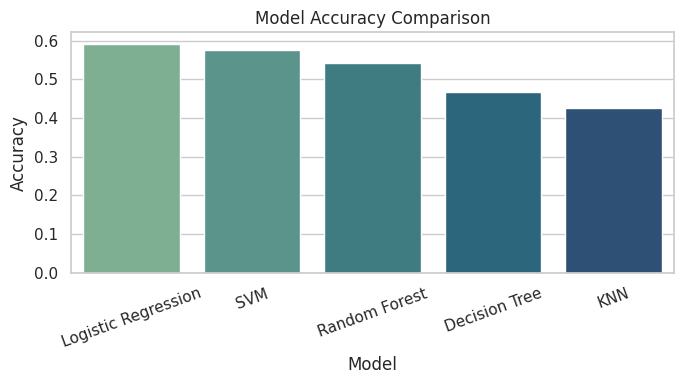

In [16]:
plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='crest')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Feature Importance (Random Forest)

Tree-based models expose `feature_importances_`, showing which
features most influence the prediction.

[feature_engineering] Feature importances:
Study_Hours_Per_Day       0.138741
Overall_Academic_Score    0.137945
Study_Efficiency          0.100756
Previous_Marks            0.097730
Attendance                0.084302
Assignment_Score          0.081737
Internal_Marks            0.076527
Internet_Usage            0.071280
Lifestyle_Balance         0.065448
Sleep_Hours               0.055530
Participation             0.037335
Age                       0.023421
Family_Support            0.020186
Gender                    0.009062
dtype: float64


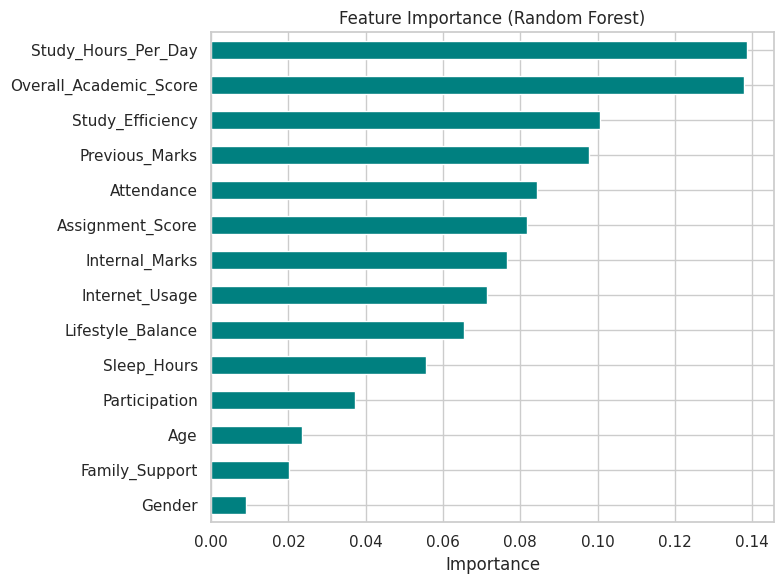

In [17]:
rf_model = all_models['Random Forest']
importances = get_feature_importance(rf_model, feature_cols)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 8. Detailed Evaluation of the Best Model

Metrics explained:
- **Accuracy** — overall % of correct predictions
- **Precision** — of predicted Pass/Average/Fail, how many were correct
- **Recall** — of actual Pass/Average/Fail, how many were correctly found
- **F1-score** — harmonic mean of precision & recall
- **Confusion Matrix** — actual vs predicted class breakdown
- **ROC Curve / AUC** — separability of each class at varying thresholds

In [18]:
class_names = list(encoders['Final_Result'].classes_)
y_pred = best_model.predict(X_test)

metrics = compute_metrics(y_test, y_pred)
metrics


[evaluation] Accuracy: 0.5917
[evaluation] Precision: 0.6021
[evaluation] Recall: 0.5917
[evaluation] F1_Score: 0.5942


{'Accuracy': 0.5916666666666667,
 'Precision': 0.6020527859237537,
 'Recall': 0.5916666666666667,
 'F1_Score': 0.5942295212898717}

In [19]:
plot_confusion_matrix(y_test, y_pred, class_names, out_dir='../outputs/graphs')


[evaluation] Saved: ../outputs/graphs/confusion_matrix.png


array([[28, 11,  9],
       [17, 19,  0],
       [11,  1, 24]])

In [20]:
report = print_classification_report(y_test, y_pred, class_names)
print(report)


[evaluation] Classification Report:
               precision    recall  f1-score   support

     Average       0.50      0.58      0.54        48
        Fail       0.61      0.53      0.57        36
        Pass       0.73      0.67      0.70        36

    accuracy                           0.59       120
   macro avg       0.61      0.59      0.60       120
weighted avg       0.60      0.59      0.59       120

              precision    recall  f1-score   support

     Average       0.50      0.58      0.54        48
        Fail       0.61      0.53      0.57        36
        Pass       0.73      0.67      0.70        36

    accuracy                           0.59       120
   macro avg       0.61      0.59      0.60       120
weighted avg       0.60      0.59      0.59       120



In [21]:
plot_roc_curves(best_model, X_test, y_test, class_names, out_dir='../outputs/graphs')


[evaluation] Saved: ../outputs/graphs/roc_curve.png


'../outputs/graphs/roc_curve.png'

## 9. Save the Best Model

We persist the trained model along with the LabelEncoders and
StandardScaler used during training, so the exact same preprocessing
can be replayed at inference time (see `src/predict.py` and `app.py`).

In [22]:
save_artifacts(best_model, encoders, scaler, feature_cols, model_dir='../models')


[train_model] Saved model + encoders + scaler + feature list -> ../models


## 10. Predict on a New Student Record

Using the saved artifacts via `predict.py`, we can predict the result
for a brand-new student.

In [23]:
from predict import predict_student

new_student = {
    'Gender': 'Female', 'Age': 18, 'Attendance': 88.0,
    'Study_Hours_Per_Day': 4.5, 'Previous_Marks': 78,
    'Assignment_Score': 82, 'Internal_Marks': 32,
    'Sleep_Hours': 7.0, 'Internet_Usage': 2.0,
    'Participation': 'High', 'Family_Support': 'High'
}

label, proba = predict_student(new_student, model_dir='../models')
print('Predicted Result:', label)
print('Class Probabilities:', proba)


Predicted Result: Pass
Class Probabilities: {'Average': 0.0732, 'Fail': 0.0016, 'Pass': 0.9253}


## 11. Conclusion

This notebook demonstrated a complete, end-to-end machine learning
workflow for predicting student academic performance: data cleaning,
EDA, feature engineering, multi-model comparison, detailed evaluation,
and a reusable prediction pipeline — all deployed via a Streamlit web
app (`app.py`) for interactive use.

See `README.md` for setup instructions and `report_content.md` for the
full internship report content.